In [23]:
import numpy  as  np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge,LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [24]:
df= pd.read_csv("house_data.csv")

In [25]:
df.head()

,size_sqft,bedrooms,age_years,price_lakh
0,650,1,12,28.5
1,800,2,8,35.2
2,950,2,5,42.0
3,1100,3,10,50.5
4,1250,3,7,58.3


In [26]:
X = df.iloc[:, :3].values   # size_sqft, bedrooms, age_years
y = df.iloc[:, -1].values 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [29]:
mn, mx = y_test.min(), y_test.max()

In [30]:
alphas = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []

In [31]:
ridge_sk = Ridge(alpha=1.0)
ridge_sk.fit(X_train_s, y_train)
y_pred_sk = ridge_sk.predict(X_test_s)

In [32]:
rmse_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_sk   = r2_score(y_test, y_pred_sk)
 

In [33]:
lr_sk = LinearRegression()
lr_sk.fit(X_train_s, y_train)
y_pred_lr = lr_sk.predict(X_test_s)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

In [34]:
print(f"\n  Weights : {ridge_sk.coef_.round(4)}")
print(f"  Bias    : {ridge_sk.intercept_:.4f}")
print(f"  RMSE    : {rmse_sk:.4f}")
print(f"  R²      : {r2_sk:.4f}")


  Weights : [15.4489  3.8396 -2.0503]
  Bias    : 60.6350
  RMSE    : 1.6153
  R²      : 0.9949


In [35]:
print(f"\n  ── Comparison ──")
print(f"  {'Model':20}  {'RMSE':>8}  {'R²':>8}")
print(f"  {'─'*40}")
print(f"  {'Linear Regression':20}  {rmse_lr:>8.4f}  {r2_lr:>8.4f}")
print(f"  {'Ridge (α=1.0)':20}  {rmse_sk:>8.4f}  {r2_sk:>8.4f}")


  ── Comparison ──
  Model                     RMSE        R²
  ────────────────────────────────────────
  Linear Regression       0.9742    0.9981
  Ridge (α=1.0)           1.6153    0.9949


In [36]:
new_houses = np.array([
    [1200, 3, 5],
    [1800, 4, 2],
    [900,  2, 10],
])

In [37]:
new_s  = scaler.transform(new_houses)
preds  = ridge_sk.predict(new_s)

In [38]:
print(f"\n  {'Size':>8}  {'Beds':>6}  {'Age':>6}  {'Ridge Predicted':>16}")
print("  " + "-" * 44)
for h, p in zip(new_houses, preds):
    print(f"  {h[0]:>8} sqft  {h[1]:>2} bed  {h[2]:>3} yr  ₹ {p:.2f} Lakh")


      Size    Beds     Age   Ridge Predicted
  --------------------------------------------
      1200 sqft   3 bed    5 yr  ₹ 56.35 Lakh
      1800 sqft   4 bed    2 yr  ₹ 82.89 Lakh
       900 sqft   2 bed   10 yr  ₹ 39.83 Lakh


Saved: ridge_regression_results.png


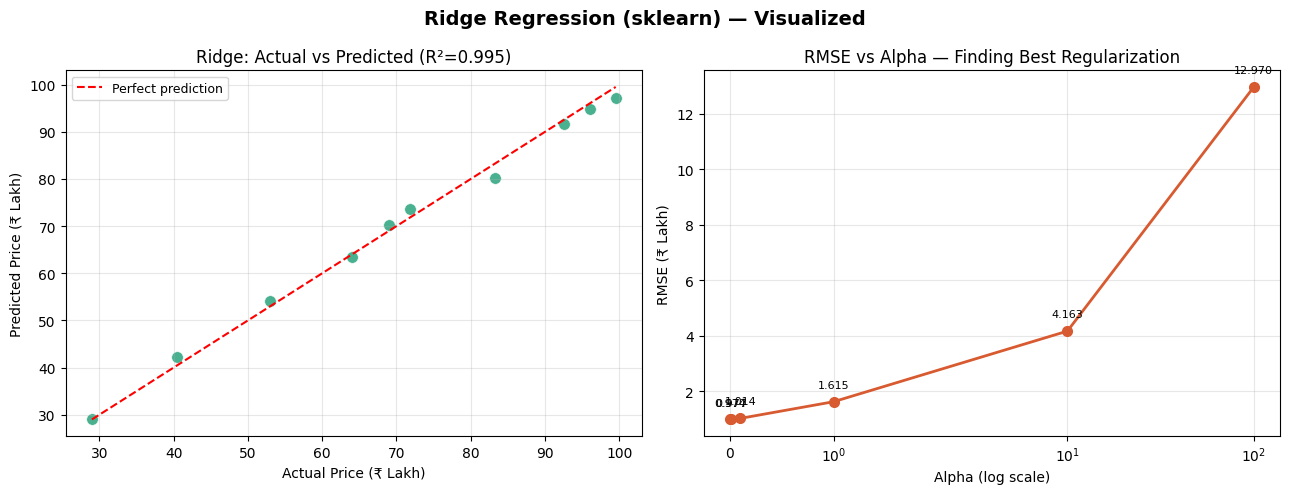

In [41]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# ── Train sklearn Ridge ───────────────────────────────
alphas    = [0.0, 0.01, 0.1, 1.0, 10.0, 100.0]
rmse_vals = []
r2_vals   = []
weight_matrix = []

for a in alphas:
    model = Ridge(alpha=a) if a > 0 else Ridge(alpha=1e-10)  # 0 ≈ plain linear
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse_vals.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_vals.append(r2_score(y_test, y_pred))
    weight_matrix.append(model.coef_.copy())

weight_matrix = np.array(weight_matrix)

# Best model (alpha=1.0)
best_model  = Ridge(alpha=1.0)
best_model.fit(X_train_s, y_train)
y_pred_sk   = best_model.predict(X_test_s)
r2_sk       = r2_score(y_test, y_pred_sk)
mn, mx      = y_test.min(), y_test.max()

# ── Plot ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # 1 row, 2 cols
fig.suptitle("Ridge Regression (sklearn) — Visualized", fontsize=14, fontweight="bold")

# Plot 1: Actual vs Predicted
ax3 = axes[0]
ax3.scatter(y_test, y_pred_sk, alpha=0.8, color="#1d9e75",
            edgecolors="white", linewidth=0.5, s=70)
ax3.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
ax3.set_title(f"Ridge: Actual vs Predicted (R²={r2_sk:.3f})")
ax3.set_xlabel("Actual Price (₹ Lakh)")
ax3.set_ylabel("Predicted Price (₹ Lakh)")
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Plot 2: RMSE vs Alpha
ax4 = axes[1]
ax4.plot(alphas, rmse_vals, marker="o", color="#d85a30",
         linewidth=2, markersize=7)
for a, rmse in zip(alphas, rmse_vals):
    ax4.annotate(f"{rmse:.3f}", (a, rmse),
                 textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")
ax4.set_xscale("symlog")
ax4.set_title("RMSE vs Alpha — Finding Best Regularization")
ax4.set_xlabel("Alpha (log scale)")
ax4.set_ylabel("RMSE (₹ Lakh)")
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ridge_regression_results.png", dpi=130, bbox_inches="tight")
print("Saved: ridge_regression_results.png")
plt.show()